# 03 — Diffusion Model (DDPM)

Baseado nas classes `GaussianDiffusion`, `PixelUNet` (adaptada para 3 canais),  
`train_diffusion` e `sample_diffusion` do notebook  
**5 - Diffusion Models and Latent Diffusion Models**.

### Checklist
- [ ] Schedule linear de betas
- [ ] Forward process `q_sample` (adicionar ruído)
- [ ] U-Net com sinusoidal time embeddings
- [ ] Loop de treino: prever ε
- [ ] Reverse sampling DDPM
- [ ] Guardar checkpoint para avaliação FID/KID

### Extensões (bónus)
- DDIM sampling (mais rápido)
- Classifier-free guidance por estilo
- Latent Diffusion (VAE + diffusion no espaço latente)

In [1]:
from __future__ import annotations
import sys, random, csv, math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

REPO_ROOT   = Path('..').resolve()
SCRIPTS_DIR = REPO_ROOT / 'TP' / 'TP1-alunos-src-only' / 'scripts'
SUBSET_CSV  = REPO_ROOT / 'TP' / 'TP1-alunos-src-only' / 'student_start_pack' / 'training_20_percent.csv'
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

def get_device():
    if torch.cuda.is_available():         return torch.device('cuda')
    if torch.backends.mps.is_available(): return torch.device('mps')
    return torch.device('cpu')

device = get_device()
print('Device:', device)

Device: mps


## 1. Hiperparâmetros

In [2]:
IMAGE_SIZE  = 32
BATCH_SIZE  = 64
LR          = 2e-4
EPOCHS      = 100
T_STEPS     = 1000     # passos de difusão
BETA_START  = 1e-4
BETA_END    = 0.02
USE_SUBSET  = True

OUT_DIR = REPO_ROOT / 'results' / 'diffusion'
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Dataset

In [3]:
def safe_num_workers():
    return 0 if 'ipykernel' in sys.modules else 2 # REVERTIDO: o multiprocessamento quebra o notebook no Mac.

class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds      = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        ex = self.ds[self.indices[idx]]
        x  = self.transform(ex['image']) if self.transform else ex['image']
        return x, int(ex['label'])

def load_ids_from_csv(csv_path, column='train_id_original'):
    ids = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        for row in csv.DictReader(f):
            v = str(row.get(column, '')).strip()
            if v: ids.append(int(v))
    print(f'Loaded {len(ids)} ids')
    return ids

transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3),
])

from datasets import load_dataset, load_from_disk

DATA_CACHE = REPO_ROOT / 'data' / 'artbench10_hf'
if DATA_CACHE.exists():
    print(f'A carregar dataset do disco: {DATA_CACHE}')
    train_hf = load_from_disk(str(DATA_CACHE))['train']
else:
    print('A fazer download do dataset (primeira vez)...')
    ds = load_dataset('zguo0525/ArtBench')
    DATA_CACHE.parent.mkdir(parents=True, exist_ok=True)
    ds.save_to_disk(str(DATA_CACHE))
    print(f'Dataset guardado em: {DATA_CACHE}')
    train_hf = ds['train']

subset_ids   = load_ids_from_csv(SUBSET_CSV) if USE_SUBSET else None
train_ds     = HFDatasetTorch(train_hf, transform, indices=subset_ids)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=safe_num_workers(), pin_memory=torch.cuda.is_available())
print(f'Amostras: {len(train_ds)} | Batches: {len(train_loader)}')


/Users/duartepereira/IAG/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


A carregar dataset do disco: /Users/duartepereira/IAG/data/artbench10_hf
Loaded 10000 ids
Amostras: 10000 | Batches: 157


## 3. `GaussianDiffusion` — copiada do notebook 5

Scheduler DDPM com schedule linear de betas. Idêntico ao notebook 5.

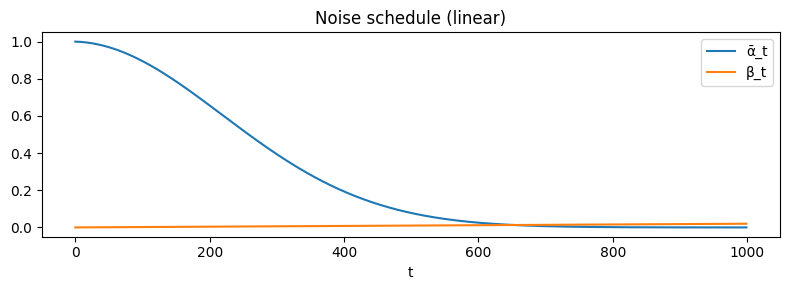

In [4]:
class GaussianDiffusion:
    """DDPM scheduler — notebook 5."""
    def __init__(self, num_timesteps=1000, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.num_timesteps = num_timesteps
        self.device        = device

        self.betas              = torch.linspace(beta_start, beta_end, num_timesteps).to(device)
        self.alphas             = 1. - self.betas
        self.alphas_cumprod     = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat([torch.tensor([1.]).to(device), self.alphas_cumprod[:-1]])

        self.sqrt_alphas_cumprod          = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)

        self.posterior_mean_coef1 = self.betas * torch.sqrt(self.alphas_cumprod_prev) / (1. - self.alphas_cumprod)
        self.posterior_mean_coef2 = (1. - self.alphas_cumprod_prev) * torch.sqrt(self.alphas) / (1. - self.alphas_cumprod)
        self.posterior_variance   = self.betas * (1. - self.alphas_cumprod_prev) / (1. - self.alphas_cumprod)

    def q_sample(self, x_0, t, noise=None):
        """Forward: adiciona ruído a x_0 no passo t."""
        if noise is None:
            noise = torch.randn_like(x_0)
        a  = self._get_index(self.sqrt_alphas_cumprod,           t, x_0.shape)
        sa = self._get_index(self.sqrt_one_minus_alphas_cumprod, t, x_0.shape)
        return a * x_0 + sa * noise

    @torch.no_grad()
    def p_sample(self, model, x, t, t_index):
        """Passo reverso: amostra x_{t-1} a partir de x_t."""
        betas_t    = self._get_index(self.betas, t, x.shape)
        sqrt_1mab  = self._get_index(self.sqrt_one_minus_alphas_cumprod, t, x.shape)
        sqrt_recip = 1. / torch.sqrt(self._get_index(self.alphas, t, x.shape))

        pred_noise = model(x, t)
        mean       = sqrt_recip * (x - betas_t * pred_noise / sqrt_1mab)

        if t_index == 0:
            return mean
        var   = self._get_index(self.posterior_variance, t, x.shape)
        noise = torch.randn_like(x)
        return mean + torch.sqrt(var) * noise

    @torch.no_grad()
    def p_sample_loop(self, model, shape):
        """Gera amostras do zero (ruído puro → imagem)."""
        model.eval()
        x = torch.randn(shape).to(self.device)
        for i in tqdm(reversed(range(self.num_timesteps)), total=self.num_timesteps,
                      desc='Sampling', leave=False):
            t = torch.full((shape[0],), i, dtype=torch.long, device=self.device)
            x = self.p_sample(model, x, t, i)
        return x

    def _get_index(self, tensor, t, x_shape):
        out = tensor.gather(-1, t)
        return out.view(t.shape[0], *((1,) * (len(x_shape) - 1)))


schedule = GaussianDiffusion(T_STEPS, BETA_START, BETA_END, device=str(device))

# visualizar schedule
plt.figure(figsize=(8, 3))
plt.plot(schedule.alphas_cumprod.cpu(), label='ᾱ_t')
plt.plot(schedule.betas.cpu(),          label='β_t')
plt.legend(); plt.title('Noise schedule (linear)'); plt.xlabel('t')
plt.tight_layout(); plt.show()


## 4. `PixelUNet` — adaptada do notebook 5 para 3 canais

Única alteração: `in_channels=3` (ArtBench RGB) em vez de `in_channels=1` (MNIST).  
Restante arquitectura (`SinusoidalPosEmb`, `ResnetBlock`, skip connections) idêntica.

In [5]:
class SinusoidalPosEmb(nn.Module):
    """Sinusoidal time embedding — notebook 5."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=x.device) * -emb)
        emb = x[:, None] * emb[None, :]
        return torch.cat((emb.sin(), emb.cos()), dim=-1)


class ResnetBlock(nn.Module):
    """Residual block com time embedding — notebook 5."""
    def __init__(self, dim, time_emb_dim, out_dim=None):
        super().__init__()
        self.out_dim  = out_dim or dim
        self.mlp      = nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, self.out_dim))
        self.conv1    = nn.Conv2d(dim,         self.out_dim, 3, padding=1)
        self.conv2    = nn.Conv2d(self.out_dim, self.out_dim, 3, padding=1)
        self.norm1    = nn.GroupNorm(4, dim)
        self.norm2    = nn.GroupNorm(4, self.out_dim)
        self.act      = nn.SiLU()
        self.shortcut = nn.Conv2d(dim, self.out_dim, 1) if dim != self.out_dim else nn.Identity()

    def forward(self, x, t_emb):
        h = self.act(self.norm1(x))
        h = self.conv1(h) + self.mlp(t_emb)[:, :, None, None]
        h = self.conv2(self.act(self.norm2(h)))
        return self.shortcut(x) + h


class PixelUNet(nn.Module):
    """
    U-Net para pixel-space diffusion — notebook 5, adaptado para in_channels=3.
    Aceita imagens 32×32 RGB (ArtBench).
    """
    def __init__(self, in_channels=3, model_channels=64):
        super().__init__()
        C, t = model_channels, model_channels * 4
        self.time_embed = nn.Sequential(
            SinusoidalPosEmb(C),
            nn.Linear(C, t), nn.SiLU(), nn.Linear(t, t),
        )
        self.init_conv  = nn.Conv2d(in_channels, C, 3, padding=1)

        # Encoder  32→16→8
        self.down1_res  = ResnetBlock(C,   t)
        self.down1_pool = nn.Conv2d(C,   C,   3, stride=2, padding=1)
        self.down2_res  = ResnetBlock(C,   t, out_dim=C*2)
        self.down2_pool = nn.Conv2d(C*2, C*2, 3, stride=2, padding=1)

        # Bottleneck  8
        self.mid_res1 = ResnetBlock(C*2, t)
        self.mid_res2 = ResnetBlock(C*2, t)

        # Decoder  8→16→32
        self.up2_conv = nn.ConvTranspose2d(C*2, C,   4, stride=2, padding=1)
        self.up2_res  = ResnetBlock(C*3, t, out_dim=C)   # skip from down2
        self.up1_conv = nn.ConvTranspose2d(C,   C,   4, stride=2, padding=1)
        self.up1_res  = ResnetBlock(C*2, t, out_dim=C)   # skip from down1

        self.out_conv = nn.Conv2d(C, in_channels, 3, padding=1)

    def forward(self, x, t):
        te   = self.time_embed(t)
        h    = self.init_conv(x)
        h1   = self.down1_res(h,             te)
        h1p  = self.down1_pool(h1)
        h2   = self.down2_res(h1p,           te)
        h2p  = self.down2_pool(h2)
        hm   = self.mid_res2(self.mid_res1(h2p, te), te)
        d2   = self.up2_res(torch.cat([self.up2_conv(hm), h2],  1), te)
        d1   = self.up1_res(torch.cat([self.up1_conv(d2), h1],  1), te)
        return self.out_conv(d1)


model = PixelUNet(in_channels=3, model_channels=64).to(device)
print(f'Parâmetros: {sum(p.numel() for p in model.parameters()):,}')


Parâmetros: 1,790,659


## 5. `train_diffusion` — notebook 5

In [6]:
def train_diffusion(model, loader, schedule, epochs=100, lr=2e-4):
    """Treino DDPM: prever ε — baseado em train_diffusion (notebook 5)."""
    opt     = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    model.train()

    for epoch in range(epochs):
        running = n_batches = 0
        for x, _ in tqdm(loader, desc=f'Epoch {epoch+1}/{epochs}', leave=False):
            x  = x.to(device)
            bs = x.shape[0]
            t  = torch.randint(0, schedule.num_timesteps, (bs,), device=device).long()

            noise  = torch.randn_like(x)
            x_t    = schedule.q_sample(x, t, noise=noise)
            pred   = model(x_t, t)
            loss   = F.mse_loss(pred, noise)

            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            running   += loss.detach()
            n_batches += 1

        avg = (running / max(n_batches, 1)).item() if hasattr(running, 'item') else running / max(n_batches, 1)
        history.append(avg)
        print(f'Epoch {epoch+1:03d}/{epochs} | loss: {avg:.5f}')

        # amostras intermédias
        if (epoch + 1) % 10 == 0:
            samples = schedule.p_sample_loop(model, shape=(16, 3, IMAGE_SIZE, IMAGE_SIZE))
            imgs    = (samples * 0.5 + 0.5).clamp(0, 1)
            save_image(imgs, OUT_DIR / f'samples_epoch{epoch+1:03d}.png', nrow=4)
            model.train()

    return history


optimizer = torch.optim.Adam(model.parameters(), lr=LR)


## 6. Treino

In [7]:
history = train_diffusion(model, train_loader, schedule, epochs=EPOCHS, lr=LR)
torch.save(model.state_dict(), OUT_DIR / 'diffusion_checkpoint.pth')
print('Checkpoint guardado.')


Epoch 1/100:   0%|          | 0/157 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 7. Curva de treino

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history)
plt.title('Diffusion training loss (MSE)'); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.savefig(OUT_DIR / 'training_curves.png')
plt.show()


## 8. Amostras geradas — `p_sample_loop` (notebook 5)

In [ ]:
samples = schedule.p_sample_loop(model, shape=(16, 3, IMAGE_SIZE, IMAGE_SIZE))
imgs_   = (samples * 0.5 + 0.5).clamp(0, 1).cpu()

grid = make_grid(imgs_, nrow=4).permute(1, 2, 0).numpy()
plt.figure(figsize=(8, 8))
plt.imshow(grid)
plt.title('DDPM — amostras geradas')
plt.axis('off')
plt.savefig(OUT_DIR / 'generated_samples.png', bbox_inches='tight')
plt.show()


## 9. (Opcional) Latent Diffusion — VAE + Diffusion no espaço latente

Dois passos:
1. Treinar o `ConvVAE` do notebook 01 e usar o encoder para comprimir as imagens
2. Treinar o `LatentDenoiseNetwork` do notebook 5 sobre os latentes

Descomenta e adapta se quiseres explorar esta extensão.

In [ ]:
# # ── carregar VAE treinado ──────────────────────────────────────────────────
# import importlib.util, sys
# # copiar a classe ConvVAE aqui ou importar de 01_vae.ipynb via nbformat
#
# vae = ConvVAE(latent_dim=128).to(device)
# vae.load_state_dict(torch.load(REPO_ROOT / 'results' / 'vae' / 'vae_checkpoint.pth'))
# for p in vae.parameters(): p.requires_grad = False
# vae.eval()
#
# # ── LatentDenoiseNetwork (notebook 5) ─────────────────────────────────────
# # latent shape: (B, 128)  →  precisamos de reformatar para (B, C_lat, H_lat, W_lat)
# # adaptar LatentDenoiseNetwork conforme necessário
#
# latent_schedule = GaussianDiffusion(T_STEPS, BETA_START, BETA_END, device=str(device))
# latent_model    = LatentDenoiseNetwork(...).to(device)
#
# encode_fn = lambda x: vae.encode(x)[0]   # usar μ como representação latente
#
# latent_history = train_diffusion(
#     latent_model, train_loader, latent_schedule,
#     encode_fn=encode_fn, epochs=50, lr=LR
# )
